### Иcпользование стратификации (уменьшаем дисперсию)

Статья: https://habr.com/ru/companies/X5Tech/articles/596279/

Идея: разбиваем нашу выборку на неперескающие подмножества, которые имеют одинаковый набор ковариат. Например, первая группа - пользователи в программе лояльности, вторая группа - остальные пользователи. 

И делаем так, чтобы в нашей контрольной и тестовой группе эти страты были в тех же пропорциях

В тесте Стьюдента мы смотрим на распределение разницы средних контрольной и тестовой группы

При стратификации мы делаем это распределение более узким, с менее тяжелыми хвостами, и снижаем дисперсию

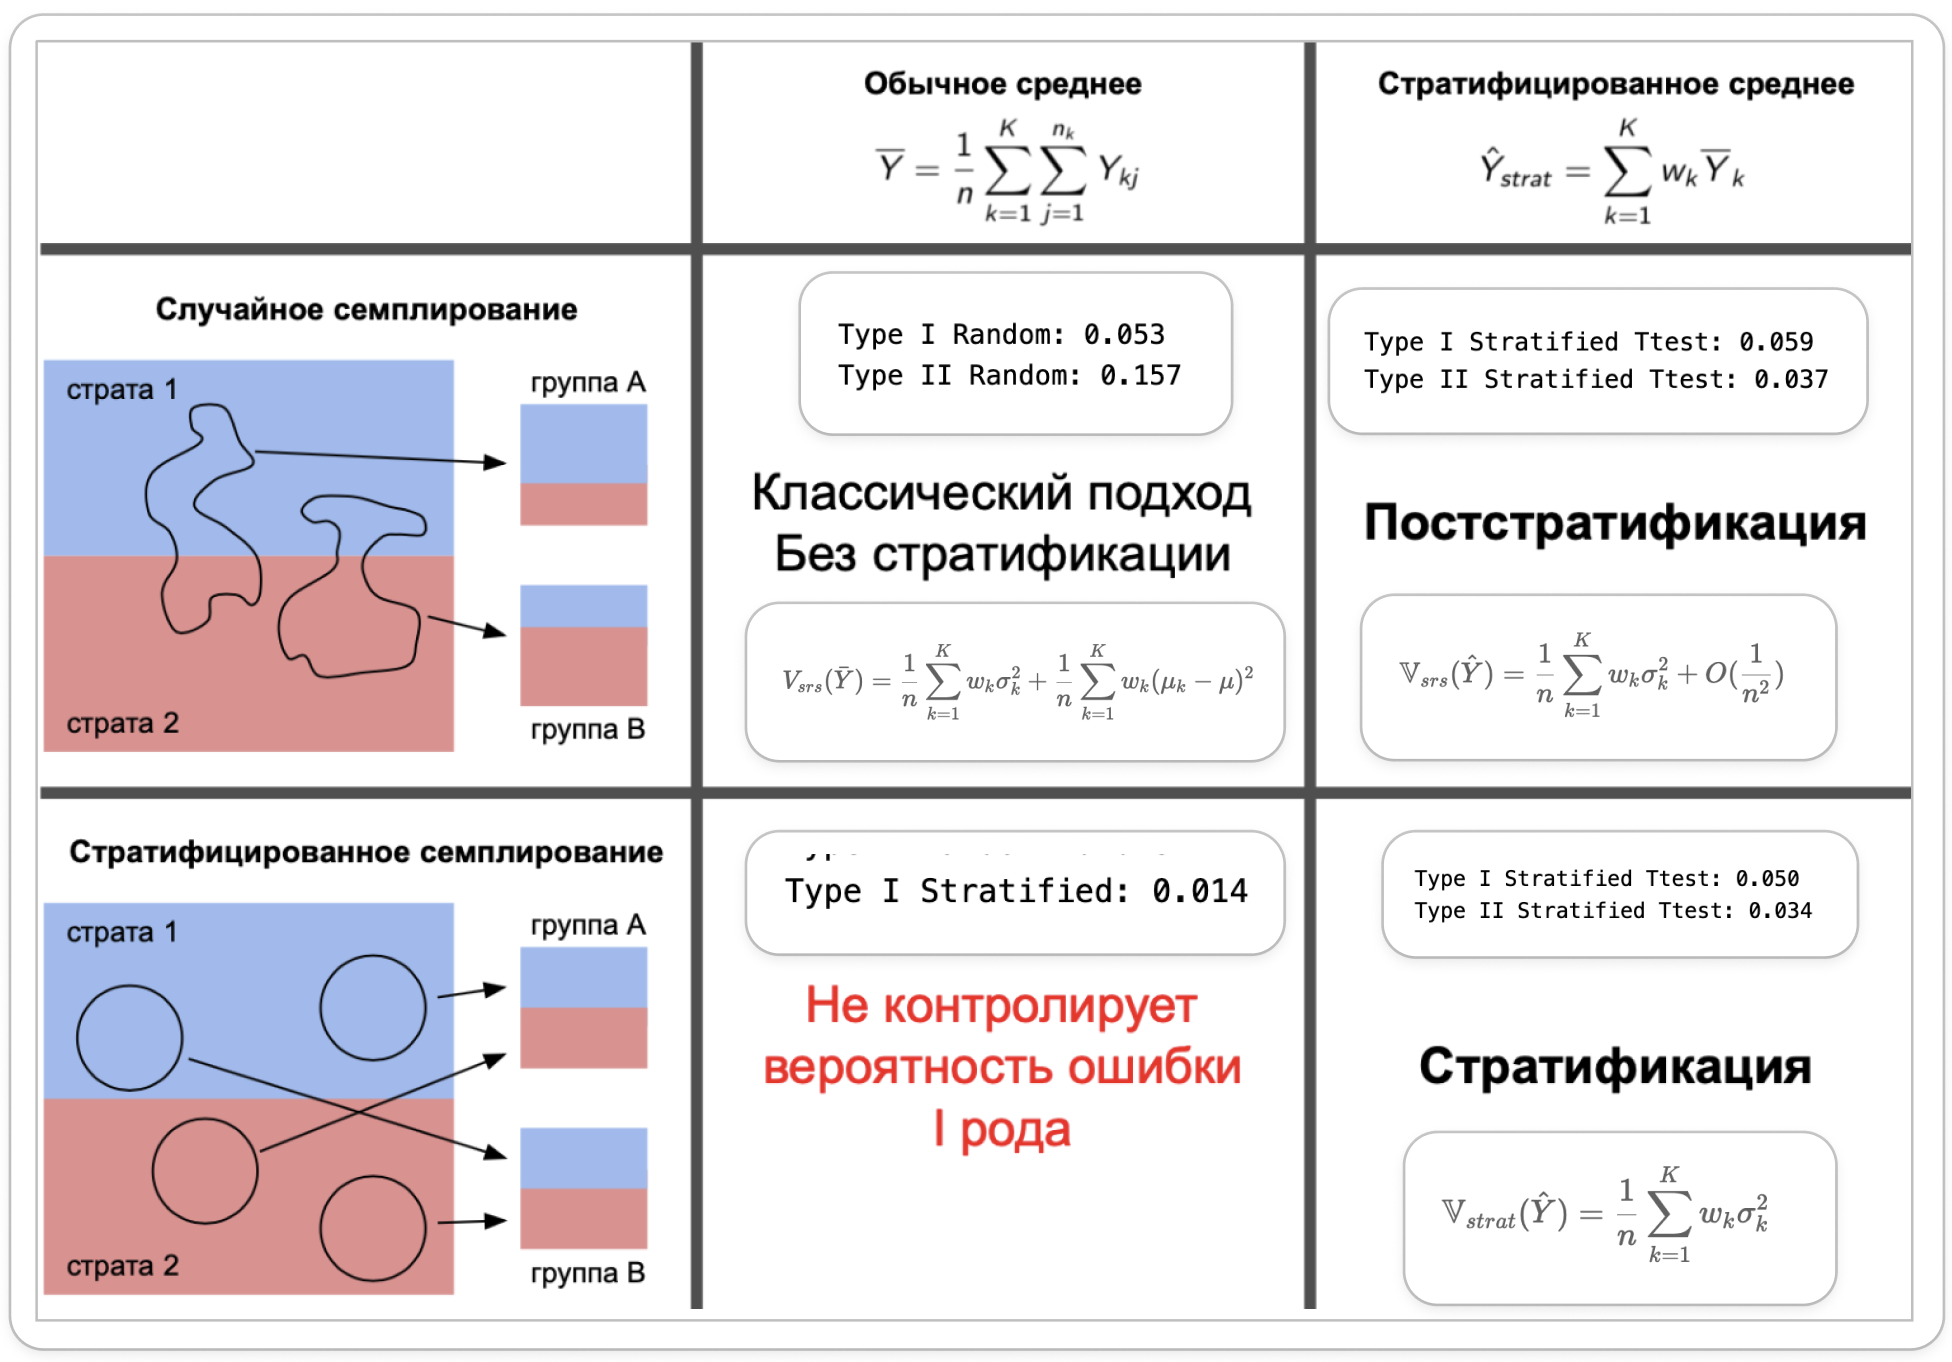

**Посмотрим на исходные распределения страт**

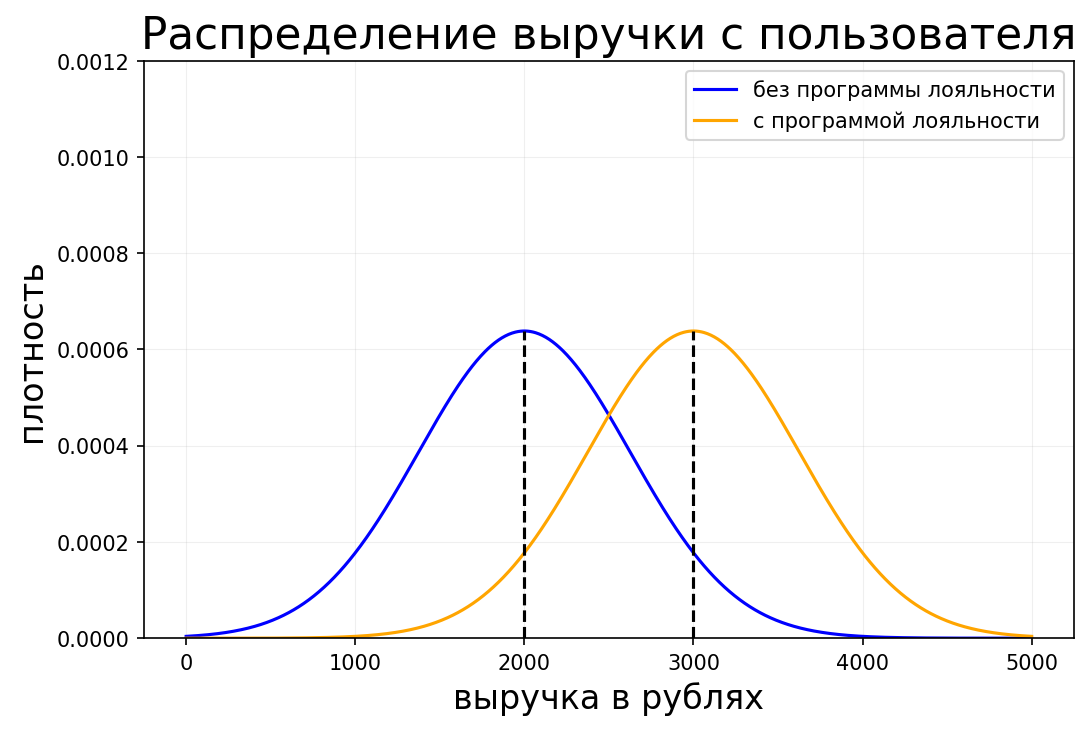

In [2]:
import numpy as np 
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
import random

plt.rcParams['figure.dpi'] = 150

plt.style.use('default')

# Parameters
n_without = 10000
n_with = 10000
mean_without = 2000
mean_with = 3000
std_both = 625

# Generate distributions
x = np.linspace(0, 5000, 1000)

# Distribution without loyalty program
dist_without = stats.norm(loc=mean_without, scale=std_both)
y_without = dist_without.pdf(x)

# Distribution with loyalty program
dist_with = stats.norm(loc=mean_with, scale=std_both)
y_with = dist_with.pdf(x)

# Plot with white background
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

peak_with = dist_with.pdf(mean_with)
peak_without = dist_without.pdf(mean_without)

ax.plot(x, y_without, label='без программы лояльности', color='blue')
ax.plot(x, y_with, label='с программой лояльности', color='orange')

# Add vertical lines for means
ax.plot([mean_without, mean_without], [0, peak_without], color='black', linestyle='--')
ax.plot([mean_with, mean_with], [0, peak_with], color='black', linestyle='--')

# Labels and formatting
ax.set_ylim(0, 0.0012)
ax.set_title('Распределение выручки с пользователя', fontsize=21)
ax.set_xlabel('выручка в рублях', fontsize=16)
ax.set_ylabel('плотность', fontsize=16)
ax.grid(alpha=0.2, linestyle='-', linewidth=0.5)

plt.legend()
plt.show()

**Сначала сделаем классический подход без стратификации**

In [4]:
# Let's find MDE and then bootstrap to check the actual Type I and type II

alpha = 0.05
beta = 0.2
mde = 100

# Our means from the sampled data
mu_control = 2500
mu_test = mu_control + mde

# Our std from the sampled data
std = 800 
var = 2 * std ** 2

# using the MDE formula to find n
# We use two-sided, meaning alpha /2
n = int(var * ((stats.norm().ppf(1 - alpha / 2) + stats.norm().ppf(1 - beta)) ** 2) / (mde ** 2))

n_iter = 10000

typeOneCount = 0
typeTwoCount = 0

for _ in range(n_iter):
    control = stats.norm(loc=mu_control, scale=std).rvs(n)
    control_other = stats.norm(loc=mu_control, scale=std).rvs(n)
    test = stats.norm(loc=mu_test, scale=std).rvs(n)

    pvalue_aa = stats.ttest_ind(control, control_other).pvalue
    if pvalue_aa <= alpha:
        typeOneCount += 1
    
    pvalue_ab = stats.ttest_ind(control, test).pvalue
    if pvalue_ab > alpha:
        typeTwoCount += 1

print(f"Type One ratio: {typeOneCount / n_iter:.3f}")
print(f"Type Two ratio: {typeTwoCount / n_iter:.3f}")

Type One ratio: 0.051
Type Two ratio: 0.201


**Теперь Делаем обычный ttest для стратифицированной и обычный выборки**

In [5]:
# General proportion of strats
w1 = 0.5
w2 = 0.5

sample_size = 1100

strat_to_param = {
    1: (int(sample_size * w1), 2000, 625),
    2: (int(sample_size * w2), 3000, 625) # loyaly group
}

def get_stratified_sampling(strat_to_param, mde):
    control = []
    test = []

    for strat in [1, 2]:
        (n, mu, std) = strat_to_param[strat]

        control += [(value, strat,) for value in stats.norm(loc=mu, scale=std).rvs(n)]
        test += [(value, strat,) for value in stats.norm(loc=mu+mde, scale=std).rvs(n)]
    
    columns = ['value', 'strat']

    control_df = pd.DataFrame(control, columns=columns)
    test_df = pd.DataFrame(test, columns=columns)

    return control_df, test_df

def get_random_sampling(strats, sample_size, strat_to_param, mde):
    control = []
    test = []

    strats_control, strats_test = np.random.choice(strats, (2, sample_size), replace=False)

    for strat in [1, 2]:
        strat_size_control = (np.array(strats_control) == strat).sum()
        strat_size_test = (np.array(strats_test) == strat).sum()

        (_, mu, std) = strat_to_param[strat]

        control += [(value, strat,) for value in stats.norm(loc=mu, scale=std).rvs(strat_size_control)]
        test += [(value, strat,) for value in stats.norm(loc=mu+mde, scale=std).rvs(strat_size_test)]
    
    columns = ['value', 'strat']

    control_df = pd.DataFrame(control, columns=columns)
    test_df = pd.DataFrame(test, columns=columns)

    return control_df, test_df

strats = [1] * int(10000 * w1) + [2] * int(10000 * w2)

random_deltas = []
stratified_deltas = []
type_one_random = []
type_one_stratified = []

alpha = 0.05

# AA test, mde=0
for _ in range(1000):
    control_random, test_random = get_random_sampling(strats, sample_size, strat_to_param, mde=0)
    control_stratified, test_stratified = get_stratified_sampling(strat_to_param, mde=0)

    random_deltas.append(test_random['value'].mean() - control_random['value'].mean())
    stratified_deltas.append(test_stratified['value'].mean() - control_stratified['value'].mean())

    pvalue_random = stats.ttest_ind(control_random['value'], test_random['value']).pvalue
    pvalue_stratified = stats.ttest_ind(control_stratified['value'], test_stratified['value']).pvalue

    type_one_random.append(pvalue_random < alpha)
    
    type_one_stratified.append(pvalue_stratified < alpha)

print(f"Type I Random: {np.array(type_one_random).mean():.3f}")
print(f"Type I Stratified: {np.array(type_one_stratified).mean():.3f}")
    


Type I Random: 0.047
Type I Stratified: 0.013


Получили уменьшение Type I примерно в 4 раза

При этом обычный ttest не знает о том, что мы используем стратификацию.     
Поэтому занижает type I error.  
Но мы же хотим тест с заданным уровнем значимости alpha  
Для корректности мы сделам свой ttest, где будем считать правильную стратифицированную дисперсию

**Посмотрим на распределение разности средних**

Text(0.5, 1.0, 'Распределение разности средних')

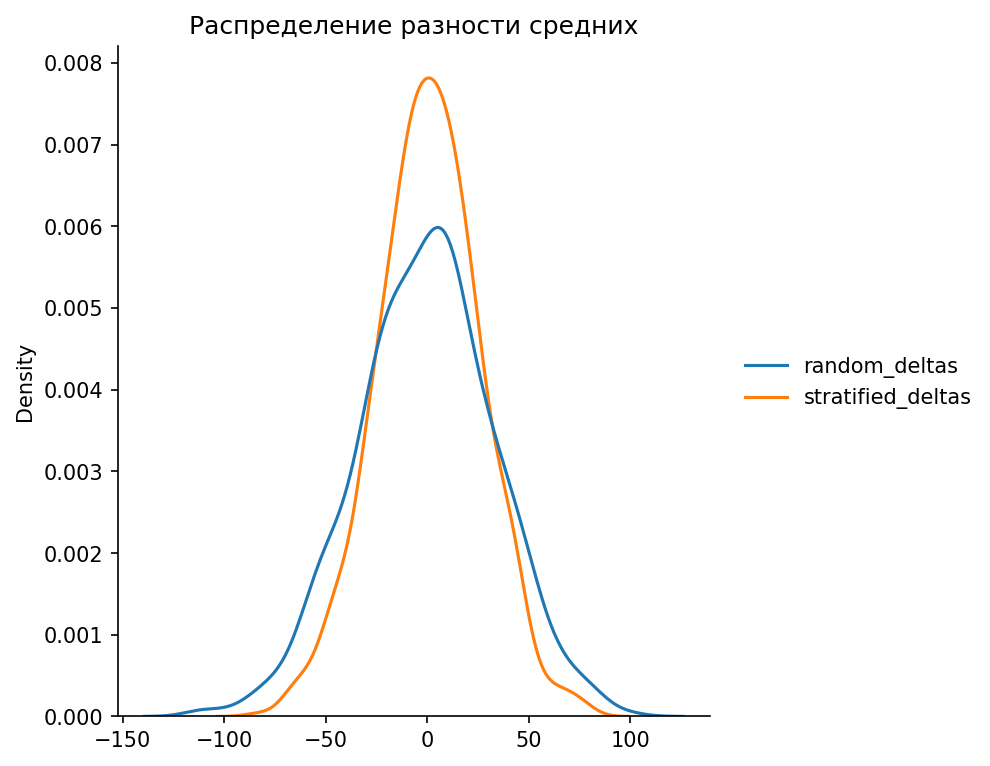

In [6]:
plt.rcParams['figure.dpi'] = 150

sns.displot({'random_deltas': random_deltas, 'stratified_deltas': stratified_deltas}, kind='kde')
plt.title("Распределение разности средних")

Видим, что стратификация уменьшила хвосты   
Это означает, что реальный доверительный интервал стал меньше   
Но тест Стьюдента об этом не знает, и поэтому и снизилась type I error

Введем обозначения:     
$\bar{Y}$ - обычное среднее, $\hat{Y}$ - стратифицированное среднее 

У них одинаковые Математическое ожидание!

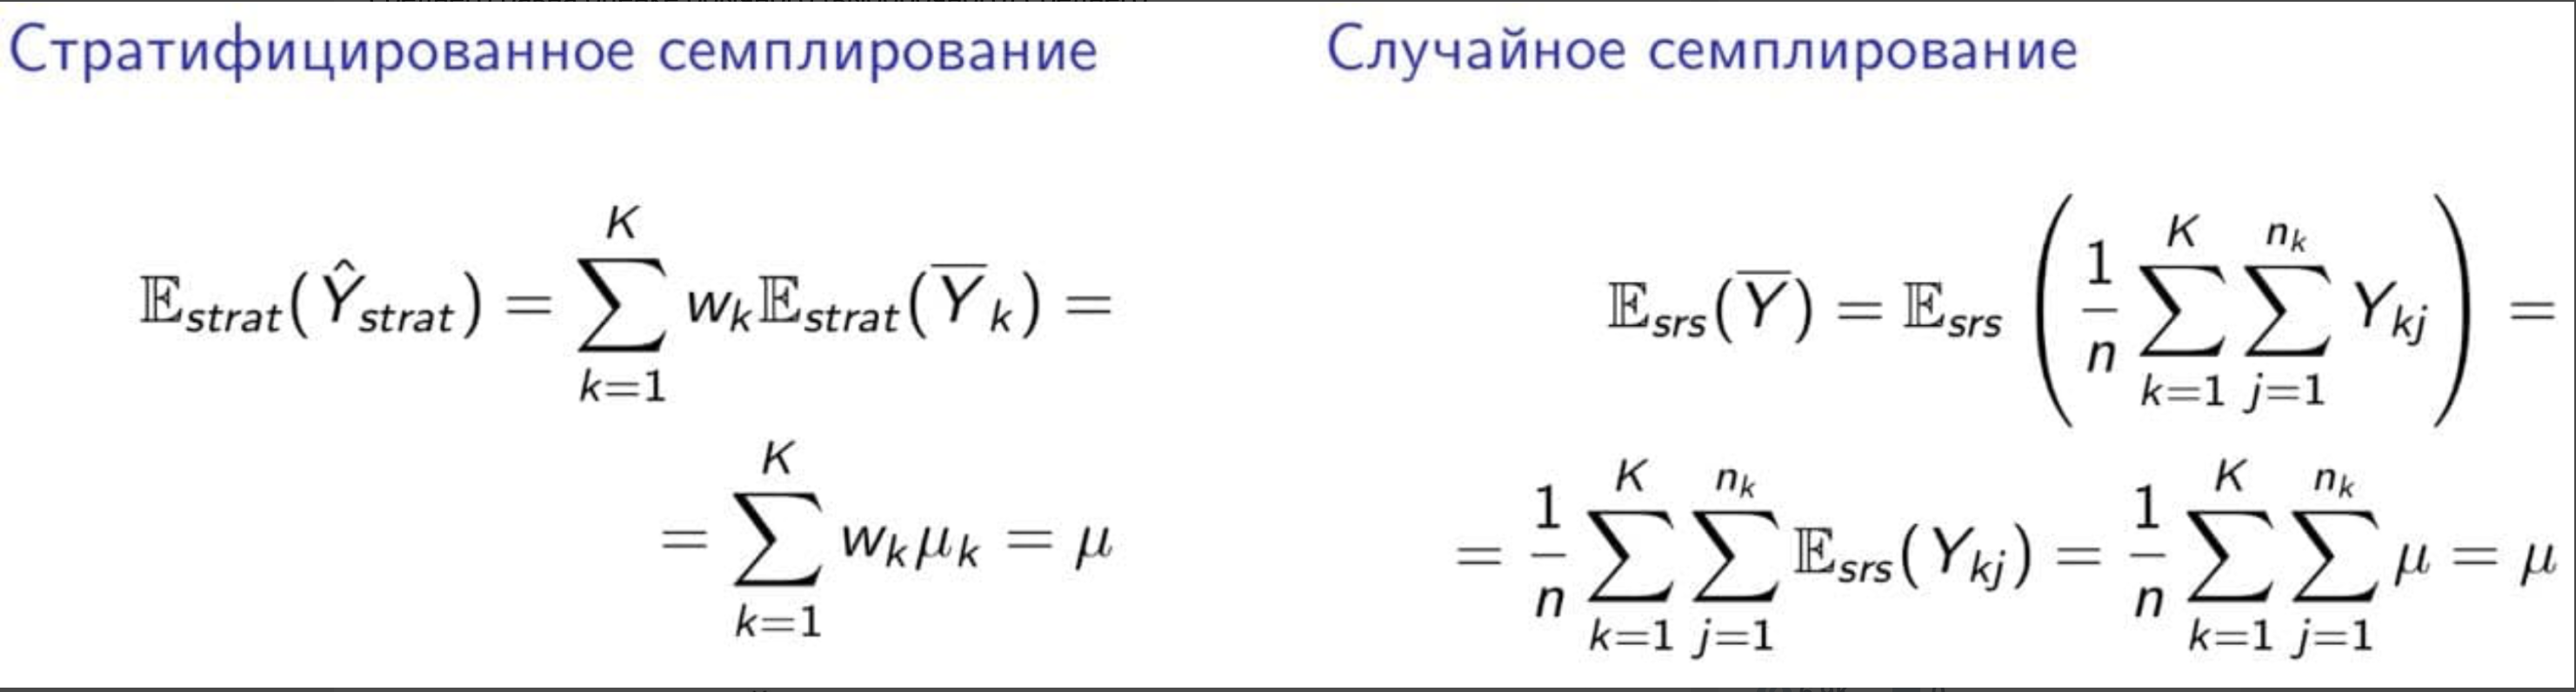

Скорректируем наш ttest, учититывая, что важно считать Математическое ожидание и Дисперсию по-другому

In [7]:
# Let's use stratified variance 

weights = pd.Series({1: 0.5, 2: 0.5})

def get_stratified_mean(df, weights):
    strat_mean = df.groupby('strat')['value'].mean()

    return (weights * strat_mean).sum()

def get_stratified_var(df, weights):
    strat_var = df.groupby('strat')['value'].var()

    return (weights * strat_var).sum()


def ttest_strat(a, b, weights):
    a_strat_mean = get_stratified_mean(a, weights)
    a_strat_var = get_stratified_var(a, weights)
    b_strat_mean = get_stratified_mean(b, weights)
    b_strat_var = get_stratified_var(b, weights)

    t = (b_strat_mean - a_strat_mean) / np.sqrt(b_strat_var / len(a) + a_strat_var / len(b))

    pvalue = 2 * min(stats.norm().cdf(t), 1 - stats.norm().cdf(t))

    return pvalue

type_one = []
type_two = []

# AA test and AB tests for stratified sampling 
for _ in range(1000):
    control_aa, test_aa = get_stratified_sampling(strat_to_param, mde=0)
    control_ab, test_ab = get_stratified_sampling(strat_to_param, mde=mde)

    pvalue_aa = ttest_strat(control_aa, test_aa, weights)
    pvalue_ab = ttest_strat(control_ab, test_ab, weights)

    type_one.append(pvalue_aa <= alpha)
    type_two.append(pvalue_ab > alpha)

print(f"Type I Stratified Ttest: {np.array(type_one).mean():.3f}")
print(f"Type II Stratified Ttest: {np.array(type_two).mean():.3f}")

Type I Stratified Ttest: 0.051
Type II Stratified Ttest: 0.044


Мы снизили Type II примерно в 5 раз

**Далее сделаем постстратификацию**

In [8]:
type_one = []
type_two = []

# AA test and AB tests for random sampling using stratified ttest (post-stratification) 
for _ in range(1000):
    control_aa, test_aa = get_random_sampling(strats, sample_size, strat_to_param, mde=0)
    control_ab, test_ab = get_random_sampling(strats, sample_size, strat_to_param, mde=mde)

    pvalue_aa = ttest_strat(control_aa, test_aa, weights)
    pvalue_ab = ttest_strat(control_ab, test_ab, weights)

    type_one.append(pvalue_aa <= alpha)
    type_two.append(pvalue_ab > alpha)

print(f"Type I Stratified Ttest: {np.array(type_one).mean():.3f}")
print(f"Type II Stratified Ttest: {np.array(type_two).mean():.3f}")

Type I Stratified Ttest: 0.053
Type II Stratified Ttest: 0.043


Получили примерно те же значения, что в обычной стратификации

## Теоретическая часть

### Разложение полной дисперсии (Stratified Variance)

Общая дисперсия случайной величины $Y$ при наличии страт (групп) $Z$ раскладывается на две составляющие:

$$V(Y) = \underbrace{E[V(Y|Z)]}_{\text{Внутригрупповая}} + \underbrace{V(E[Y|Z])}_{\text{Межгрупповая}}$$

#### 1. Внутригрупповая дисперсия (Within-group)
Это средневзвешенная дисперсия внутри каждой страты:
$$E[V(Y|Z)] = \sum_{k=1}^K w_k \sigma_k^2$$
*Где $w_k$ — вес группы, $\sigma_k^2$ — дисперсия в группе $k$.*

#### 2. Межгрупповая дисперсия (Between-group)
Это дисперсия средних значений групп относительно общего среднего $\mu$:
$$V(E[Y|Z]) = \sum_{k=1}^K w_k (\mu_k - \mu)^2$$
*Где $\mu_k$ — среднее значение в группе $k$.*

#### Итоговая формула:
$$V_{srs}(Y) = \sum_{k=1}^K w_k \sigma_k^2 + \sum_{k=1}^K w_k (\mu_k - \mu)^2$$

$$V_{srs}(\bar{Y}) = \frac{1}{n} \sum_{k=1}^K w_k \sigma_k^2 + \frac{1}{n} \sum_{k=1}^K w_k (\mu_k - \mu)^2$$

$\text{srs}$ - simple random sampling

---
**Зачем это в A/B тестах?**
Стратификация позволяет исключить **второе слагаемое** (межгрупповую разницу) из общей ошибки. Это снижает дисперсию оценки, что делает тест мощнее (позволяет поймать меньший эффект на той же выборке).

При **стратифицированном выборе** с пропорциональным распределением ($n_k = n \cdot w_k$) веса $w_k$ становятся **константами**, а средние по стратам $\bar{Y}_k$ — независимыми величинами:

$$\hat{Y} = \sum w_k \bar{Y}_k \text{ (фиксируем размер каждого кластера!)}$$

$$\mathbb{V}_{strat}(\hat{Y}) = \mathbb{V}\left( \sum w_k \bar{Y}_k \right) = \sum w_k^2 \mathbb{V}(\bar{Y}_k) = \sum w_k^2 \frac{\sigma_k^2}{n \cdot w_k} = \frac{1}{n} \sum_{k=1}^K w_k \sigma_k^2$$

$$\mathbb{V}_{strat}(\hat{Y}) = \frac{1}{n} \sum_{k=1}^K w_k \sigma_k^2$$

Индексы srs и strat у дисперсии означают способ семплирования данных - случайное и стратифицированное соответственно

---
**Постстратификация**

Мы считаем $\hat{Y}$, используя реальные веса $w_k$, несмотря на то, что мы не контролировали $n_k$ во время сэмплинга: $n_k \neq n \cdot w_k$

$$\mathbb{V}_{srs}(\hat{Y}) = \frac{1}{n} \sum_{k=1}^K w_k \sigma_k^2 + O(\frac{1}{n^2})$$

В итоге получили, что 

$$\mathbb{V}_{strat}(\hat{Y}) <= \mathbb{V}_{srs}(\hat{Y}) <= \mathbb{V}_{srs}(\bar{Y})$$